# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 7
- **Date:** 07.09.2026

---

In [5]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-07"

print("Notebook Loaded Successfully")

Notebook Loaded Successfully


In [6]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)

Notebook Fingerprint:
95bb4f74f0bdcdb61f1c8ff56c99f04450f6e474689096f3b46232b31b9f6bac


# Experiment Details

## Objective

To implement a **Support Vector Machine (SVM) Classifier** using the
*Breast Cancer Wisconsin (Diagnostic) Dataset* (UCI ML Repository, ID: 17),
in order to classify tumours as **Malignant** or **Benign** based on 30 numeric
cell-nucleus features extracted from digitised FNA images, and to evaluate the model
using standard classification metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC)
along with kernel comparison, C-parameter sensitivity study, confusion-matrix
visualisation, and ROC curve analysis.

---

## Theory

A **Support Vector Machine (SVM)** is a supervised learning algorithm that finds the
optimal **hyperplane** separating two classes with the **maximum margin**. It is
particularly effective in high-dimensional spaces and remains robust when the number
of features exceeds the number of samples.

### Decision Hyperplane

For a binary classification problem with input $\mathbf{x} \in \mathbb{R}^d$,
the SVM decision boundary is a hyperplane defined by:

$$\mathbf{w}^\top \mathbf{x} + b = 0$$

where $\mathbf{w}$ is the weight vector (normal to the hyperplane) and $b$ is the bias.

The predicted class is:

$$\hat{y} = \text{sign}(\mathbf{w}^\top \mathbf{x} + b)$$

### Margin Maximisation (Hard-Margin SVM)

The **margin** is the distance between the two parallel supporting hyperplanes
$\mathbf{w}^\top \mathbf{x} + b = \pm 1$:

$$\text{Margin} = \frac{2}{\|\mathbf{w}\|}$$

SVM maximises the margin by solving:

$$\min_{\mathbf{w},b}\ \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{subject to} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 \;\;\forall\, i$$

### Soft-Margin SVM (C-Parameter)

For non-linearly-separable data, slack variables $\xi_i \geq 0$ allow misclassifications:

$$\min_{\mathbf{w},b,\boldsymbol{\xi}}\ \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^{n}\xi_i$$

$$\text{subject to} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i,\quad \xi_i \geq 0$$

The **regularisation parameter $C$** controls the bias-variance trade-off:
- Large $C$ → low bias, high variance (hard margin, few misclassifications tolerated)
- Small $C$ → high bias, low variance (soft margin, more violations allowed)

### Kernel Trick

For non-linear boundaries, SVM uses a **kernel function** $K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^\top \phi(\mathbf{x}_j)$
to implicitly map data into a higher-dimensional feature space without computing $\phi$ explicitly.

The dual decision function becomes:

$$f(\mathbf{x}) = \text{sign}\!\left(\sum_{i \in \text{SV}} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b\right)$$

**Common kernel functions:**

| Kernel | Formula |
|--------|---------|
| Linear | $K(\mathbf{x},\mathbf{z}) = \mathbf{x}^\top\mathbf{z}$ |
| Polynomial | $K(\mathbf{x},\mathbf{z}) = (\gamma\,\mathbf{x}^\top\mathbf{z} + r)^d$ |
| RBF (Gaussian) | $K(\mathbf{x},\mathbf{z}) = \exp\!\left(-\gamma\|\mathbf{x}-\mathbf{z}\|^2\right)$ |
| Sigmoid | $K(\mathbf{x},\mathbf{z}) = \tanh(\gamma\,\mathbf{x}^\top\mathbf{z} + r)$ |

### Support Vectors

**Support vectors** are the training points that lie on or within the margin
($\alpha_i > 0$). Only these points determine the hyperplane — removing
non-support-vector points does not change the decision boundary.

### Feature Scaling

SVM is sensitive to feature magnitudes because the margin computation depends on
$\|\mathbf{w}\|$ and kernel distances. **StandardScaler** (zero mean, unit variance)
is mandatory before training:

$$x' = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

### Evaluation Metrics

| Metric | Formula |
|--------|---------|
| Accuracy | $\dfrac{TP + TN}{TP + TN + FP + FN}$ |
| Precision | $\dfrac{TP}{TP + FP}$ |
| Recall (Sensitivity) | $\dfrac{TP}{TP + FN}$ |
| F1-Score | $2 \cdot \dfrac{P \cdot R}{P + R}$ |
| ROC-AUC | Area under the Receiver Operating Characteristic curve |

---

## Dataset

- **Name:** Breast Cancer Wisconsin (Diagnostic) Dataset
- **Source:** UCI Machine Learning Repository (ID: 17)  
  — https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- **Total Instances:** 569 tumour samples
- **Features (30):** Numeric measurements computed for each cell nucleus —  
  mean, standard error, and worst value of:  
  radius, texture, perimeter, area, smoothness, compactness,  
  concavity, concave_points, symmetry, fractal_dimension
- **Target:** `diagnosis` — M = Malignant (1), B = Benign (0)
- **Class Distribution:** 357 Benign (62.7%), 212 Malignant (37.3%)
- **Missing Values:** None
- **File Format:** CSV with no header; ID is col 0, diagnosis is col 1, features col 2–31
- **Task Type:** Binary Classification
- **Licence:** CC BY 4.0


In [7]:
# Step 1 — Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os, zipfile, glob
import urllib.request

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")

All libraries imported successfully.


In [8]:
# Step 2 — Download and load the UCI Breast Cancer Wisconsin dataset (ID: 17)

DATA_URL = "https://archive.ics.uci.edu/static/public/17/breast+cancer+wisconsin+diagnostic.zip"
DATA_DIR = "bc_data"
os.makedirs(DATA_DIR, exist_ok=True)

zip_path = os.path.join(DATA_DIR, "dataset.zip")
if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    print("Download complete.")
else:
    print("Dataset archive already present.")

with zipfile.ZipFile(zip_path) as zf:
    print("Zip contents:", zf.namelist())
    zf.extractall(DATA_DIR)

data_files = glob.glob(os.path.join(DATA_DIR, "**", "*.data"), recursive=True)
print("Data files found:", data_files)

# Col 0 = ID (drop), Col 1 = diagnosis, Col 2-31 = 30 features
FEATURE_NAMES = []
for stat in ["mean", "se", "worst"]:
    for meas in ["radius", "texture", "perimeter", "area", "smoothness",
                 "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"]:
        FEATURE_NAMES.append(f"{meas}_{stat}")

COLUMNS = ["id", "diagnosis"] + FEATURE_NAMES

df_raw = pd.read_csv(data_files[0], header=None, names=COLUMNS)
df_raw = df_raw.drop(columns=["id"])          # ID not useful for modelling

print("\nDataset loaded successfully.")
print("Shape:", df_raw.shape)
print(df_raw.head())

Download complete.
Zip contents: ['wdbc.data', 'wdbc.names']
Data files found: ['bc_data\\wdbc.data']

Dataset loaded successfully.
Shape: (569, 31)
  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.198

In [9]:
# Step 3 — Dataset overview

print("Dataset  : Breast Cancer Wisconsin (Diagnostic)")
print("Samples  :", df_raw.shape[0])
print("Columns  :", df_raw.shape[1])
print("Source   : UCI ML Repository (ID: 17)")
print("Target   : diagnosis (M = Malignant, B = Benign)")

Dataset  : Breast Cancer Wisconsin (Diagnostic)
Samples  : 569
Columns  : 31
Source   : UCI ML Repository (ID: 17)
Target   : diagnosis (M = Malignant, B = Benign)


In [10]:
# Step 4 — Explore dataset structure

print("Shape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nFirst 10 rows:")
print(df_raw.head(10))

Shape: (569, 31)

Column names: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

First 10 rows:
  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          

In [11]:
# Step 5 — Data types and unique value counts

print("Dataset Info:")
df_raw.info()
print("\nData Types:")
print(df_raw.dtypes)
print("\nUnique Values per Column:")
print(df_raw.nunique())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                

In [12]:
# Step 6 — Check for missing values and duplicates

missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print("\nTotal missing values:", df_raw.isnull().sum().sum())
print("\nDuplicate records   :", df_raw.duplicated().sum())

Missing values per column:
No missing values found.

Total missing values: 0

Duplicate records   : 0


Target variable distribution (diagnosis):
diagnosis
B    357
M    212
Name: count, dtype: int64

Class proportions (%):
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


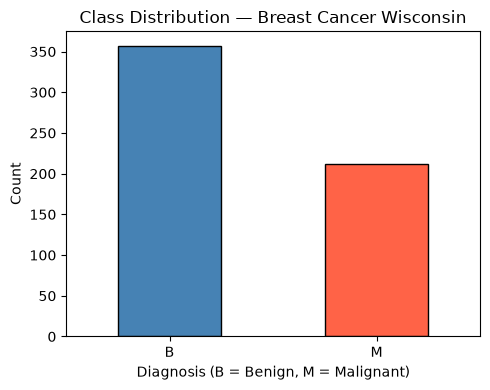

In [13]:
# Step 7 — Target class distribution

print("Target variable distribution (diagnosis):")
print(df_raw["diagnosis"].value_counts())
print("\nClass proportions (%):")
print(round(df_raw["diagnosis"].value_counts(normalize=True) * 100, 2))

plt.figure(figsize=(5, 4))
df_raw["diagnosis"].value_counts().plot(
    kind="bar", color=["steelblue", "tomato"], edgecolor="black"
)
plt.title("Class Distribution — Breast Cancer Wisconsin")
plt.xlabel("Diagnosis (B = Benign, M = Malignant)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# Step 8 — Statistical summary

print("Statistical Summary (Numerical Features):")
print(df_raw.describe())

Statistical Summary (Numerical Features):
       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        

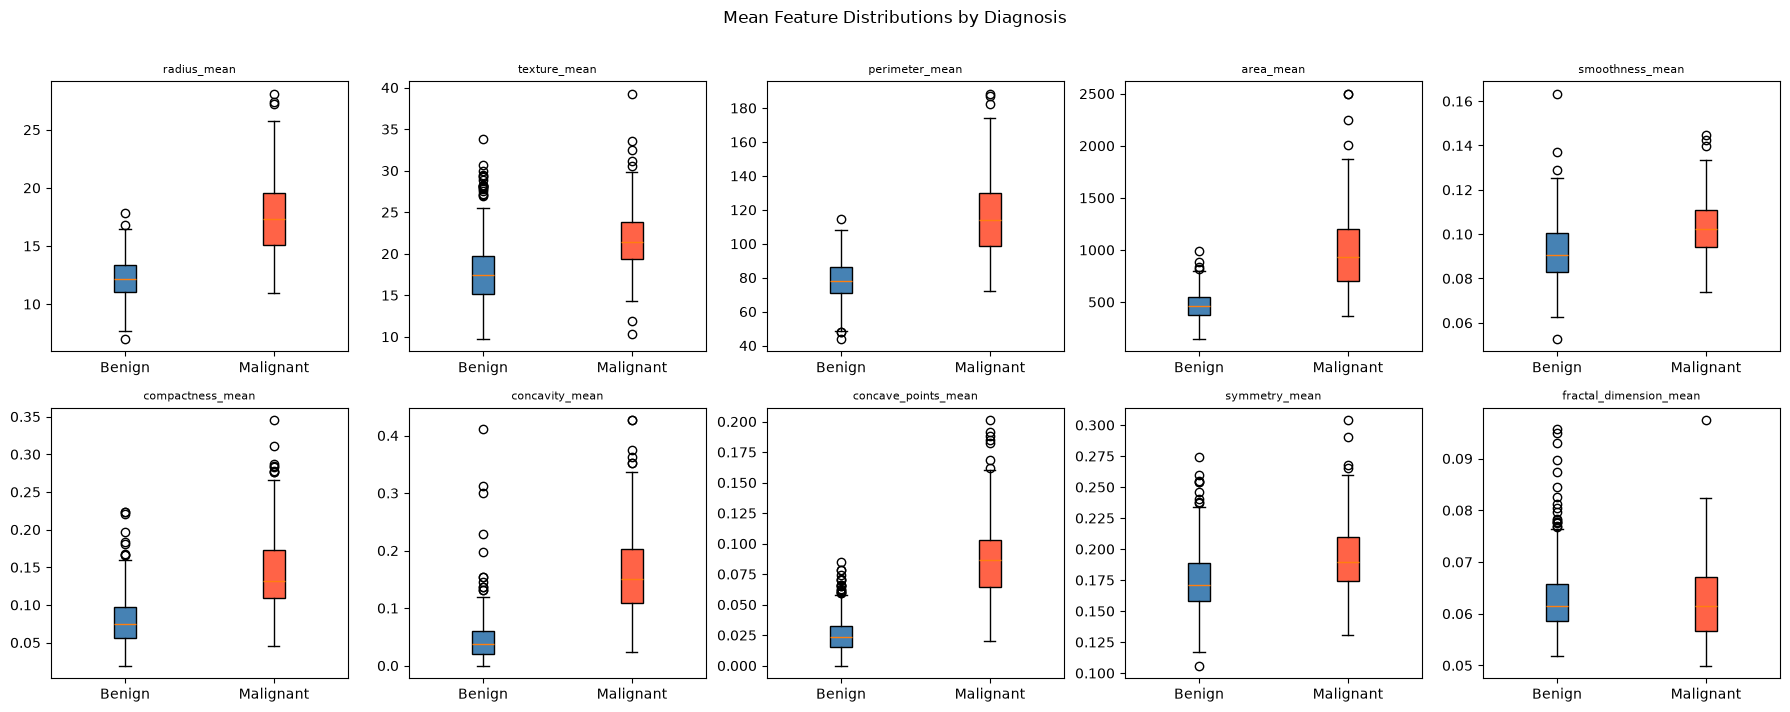

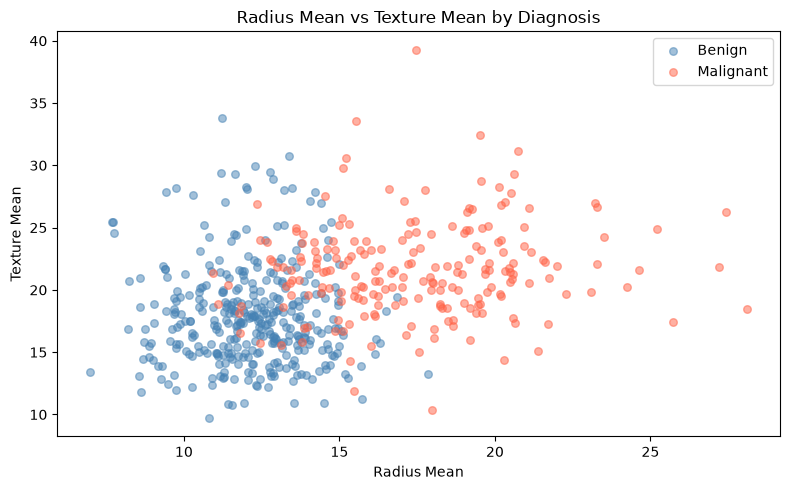

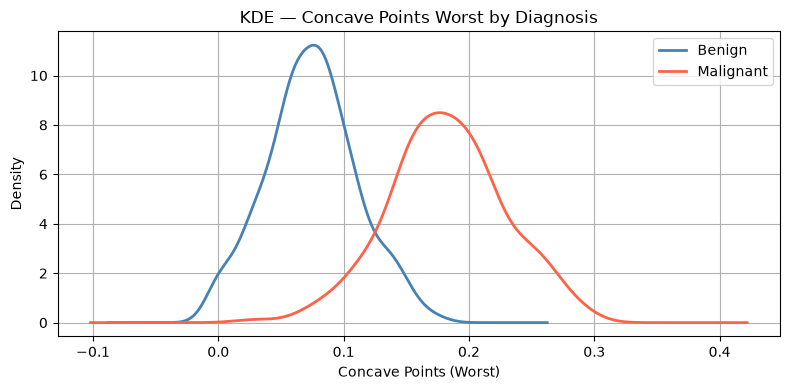

In [15]:
# Step 9 — Exploratory Data Analysis

# 9a. Box plots — mean features by diagnosis
mean_cols = [c for c in df_raw.columns if c.endswith("_mean")]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(mean_cols):
    data_by_class = [df_raw[df_raw["diagnosis"] == k][col].values for k in ["B", "M"]]
    bp = axes[i].boxplot(data_by_class, tick_labels=["Benign","Malignant"], patch_artist=True)
    for patch, c in zip(bp["boxes"], ["steelblue", "tomato"]):
        patch.set_facecolor(c)
    axes[i].set_title(col, fontsize=8)
plt.suptitle("Mean Feature Distributions by Diagnosis", y=1.01)
plt.tight_layout()
plt.show()

# 9b. Radius mean vs Texture mean
plt.figure(figsize=(8, 5))
for cls, colour in zip(["B", "M"], ["steelblue", "tomato"]):
    sub = df_raw[df_raw["diagnosis"] == cls]
    plt.scatter(sub["radius_mean"], sub["texture_mean"],
                label=f"{'Benign' if cls=='B' else 'Malignant'}",
                alpha=0.5, s=30, c=colour)
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("Radius Mean vs Texture Mean by Diagnosis")
plt.legend()
plt.tight_layout()
plt.show()

# 9c. KDE — concave_points_worst (highest discriminative power)
plt.figure(figsize=(8, 4))
for cls, colour in zip(["B","M"], ["steelblue","tomato"]):
    df_raw[df_raw["diagnosis"]==cls]["concave_points_worst"].plot.kde(
        label="Benign" if cls=="B" else "Malignant", color=colour, lw=2)
plt.xlabel("Concave Points (Worst)")
plt.title("KDE — Concave Points Worst by Diagnosis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Step 10 — Preprocessing: encode target label

df = df_raw.drop_duplicates().copy()

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])   # B=0, M=1

print("Classes mapped:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")
print("\nFirst 5 rows after encoding:")
print(df.head())

Classes mapped:
  0 -> B
  1 -> M

First 5 rows after encoding:
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  fractal_dimension_mean  radius_se 

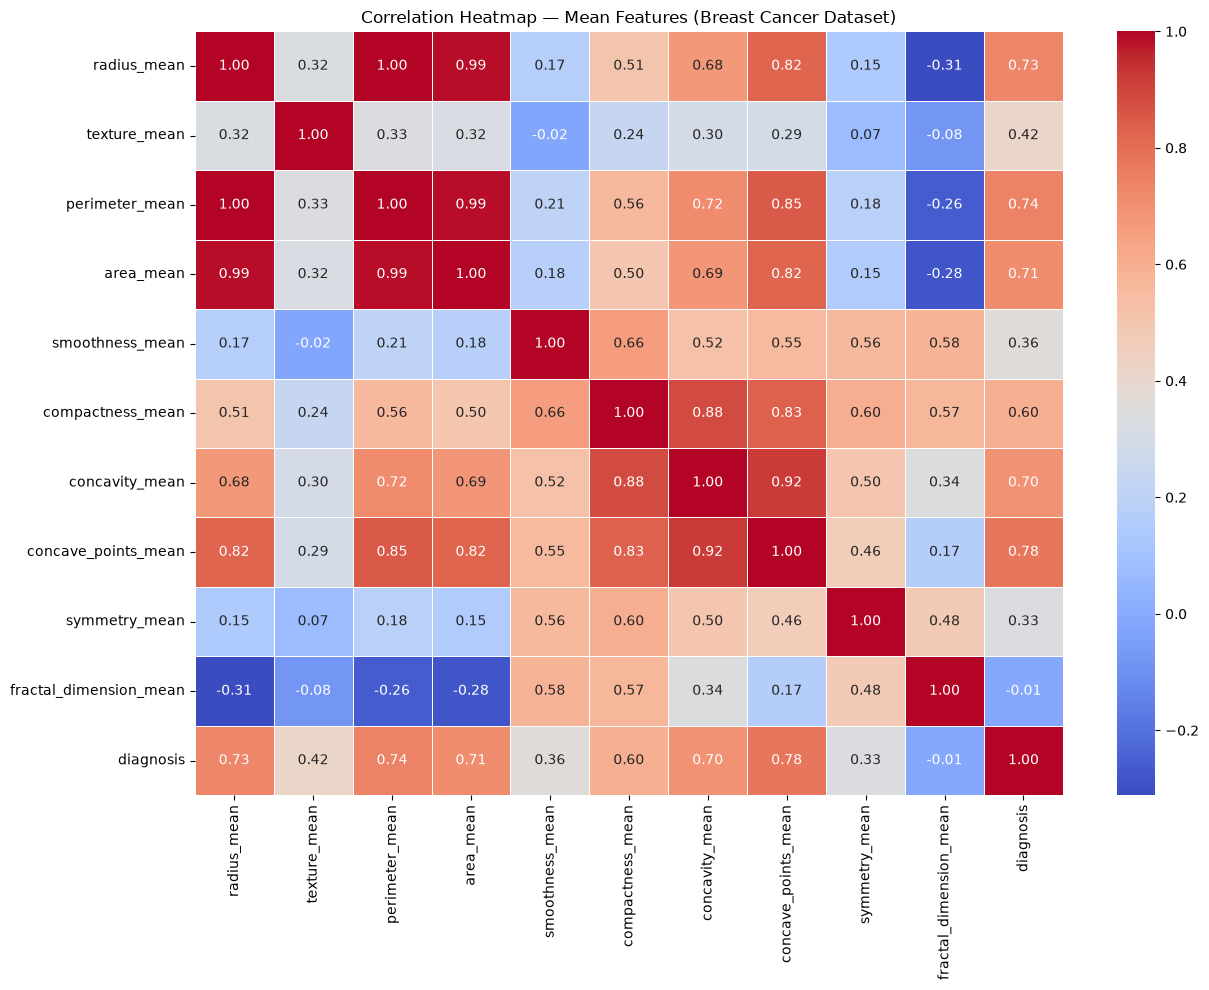


Top 10 features by correlation with diagnosis:
concave_points_worst    0.793566
perimeter_worst         0.782914
concave_points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64


In [17]:
# Step 11 — Correlation heatmap (mean features only for readability)

mean_cols = [c for c in df.columns if c.endswith("_mean")] + ["diagnosis"]
plt.figure(figsize=(13, 10))
sns.heatmap(
    df[mean_cols].corr(),
    cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5
)
plt.title("Correlation Heatmap — Mean Features (Breast Cancer Dataset)")
plt.tight_layout()
plt.show()

target_corr = df.corr()["diagnosis"].drop("diagnosis").abs().sort_values(ascending=False)
print("\nTop 10 features by correlation with diagnosis:")
print(target_corr.head(10))

In [18]:
# Step 12 — Feature/target split and train-test split

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size :", X_train.shape)
print("Test set size     :", X_test.shape)
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

Training set size : (455, 30)
Test set size     : (114, 30)

Training class distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64


In [19]:
# Step 13 — Feature Scaling (StandardScaler)
# SVM margin computation depends on ||w|| and kernel distances — scaling is mandatory.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Feature scaling completed.")
print("Mean of first feature (train, after scaling):", round(X_train_sc[:, 0].mean(), 6))
print("Std  of first feature (train, after scaling):", round(X_train_sc[:, 0].std(),  6))

Feature scaling completed.
Mean of first feature (train, after scaling): -0.0
Std  of first feature (train, after scaling): 1.0


In [20]:
# Step 14 — Train the SVM Classifier (RBF Kernel)

model = SVC(
    kernel="rbf",          # Radial Basis Function kernel
    C=1.0,                 # regularisation parameter
    gamma="scale",         # kernel coefficient
    probability=True,      # enable predict_proba for ROC-AUC
    random_state=42
)

model.fit(X_train_sc, y_train)

print("SVM Classifier trained successfully.")
print("Kernel           :", model.kernel)
print("C (regulariser)  :", model.C)
print("Gamma            :", model.gamma)
print("Support vectors  :", model.n_support_)
print("Total SVs        :", sum(model.n_support_))

SVM Classifier trained successfully.
Kernel           : rbf
C (regulariser)  : 1.0
Gamma            : scale
Support vectors  : [50 57]
Total SVs        : 107


c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [21]:
# Step 15 — Predictions and evaluation metrics

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

acc       = accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred)
rec       = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("       MODEL EVALUATION SUMMARY")
print("=" * 45)
print(f"Accuracy  : {acc       * 100:.2f} %")
print(f"Precision : {prec      * 100:.2f} %")
print(f"Recall    : {rec       * 100:.2f} %")
print(f"F1-Score  : {f1        * 100:.2f} %")
print(f"ROC-AUC   : {auc_score:.4f}")
print("=" * 45)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))

       MODEL EVALUATION SUMMARY
Accuracy  : 97.37 %
Precision : 100.00 %
Recall    : 92.86 %
F1-Score  : 96.30 %
ROC-AUC   : 0.9947

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion Matrix:
[[72  0]
 [ 3 39]]


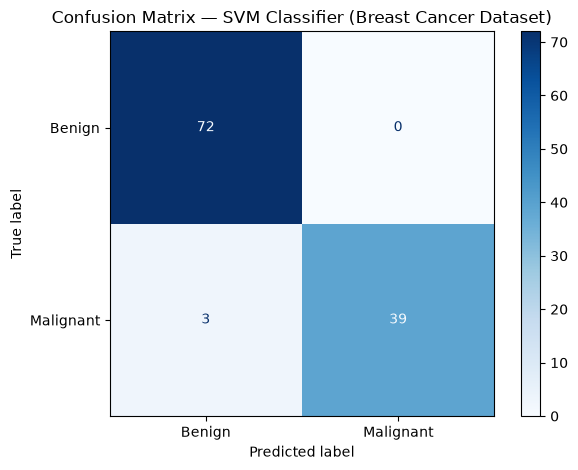

In [22]:
# Step 16 — Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — SVM Classifier (Breast Cancer Dataset)")
plt.tight_layout()
plt.show()

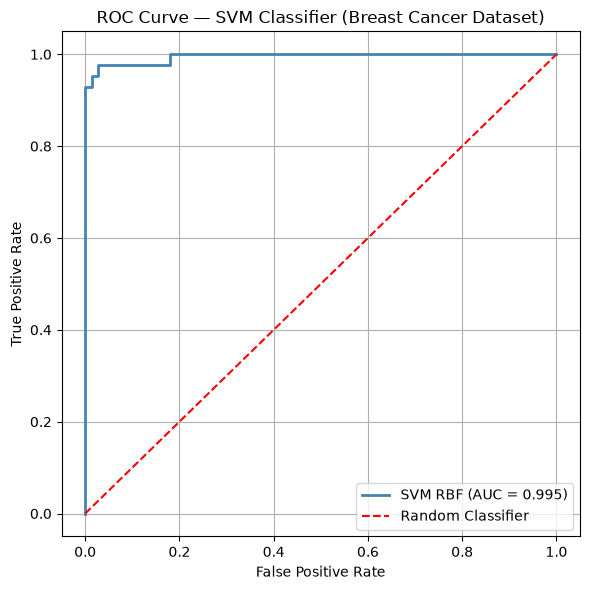

In [23]:
# Step 17 — ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"SVM RBF (AUC = {roc_auc:.3f})",
         color="steelblue", lw=2)
plt.plot([0, 1], [0, 1], "r--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SVM Classifier (Breast Cancer Dataset)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\

 Kernel  Test Accuracy (%)  F1-Score (%)
 linear              96.49         95.00
    rbf              97.37         96.30
   poly              88.60         81.69
sigmoid              94.74         92.50


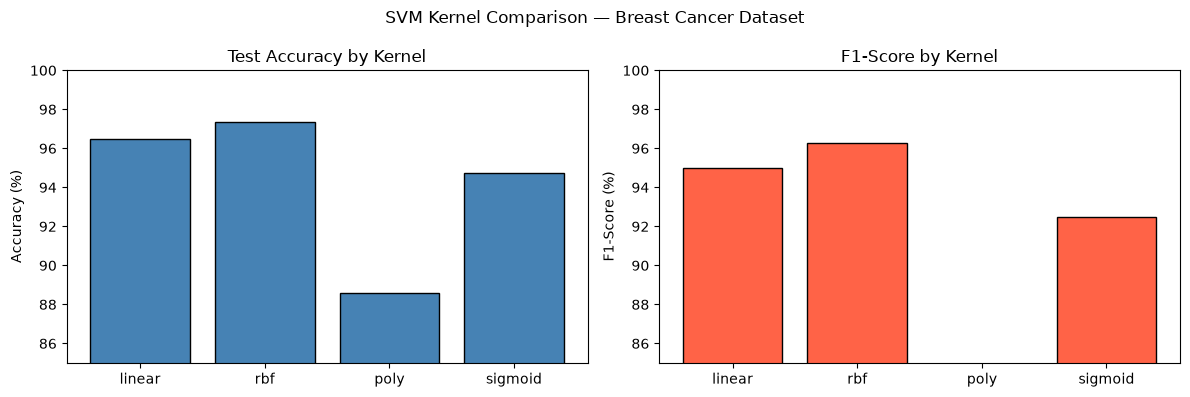

In [24]:
# Step 18 — Kernel Comparison

kernels = ["linear", "rbf", "poly", "sigmoid"]
kernel_results = []

for k in kernels:
    svm = SVC(kernel=k, C=1.0, gamma="scale", probability=True, random_state=42)
    svm.fit(X_train_sc, y_train)
    y_kpred = svm.predict(X_test_sc)
    test_acc = accuracy_score(y_test, y_kpred)
    test_f1  = f1_score(y_test, y_kpred)
    kernel_results.append({
        "Kernel": k,
        "Test Accuracy (%)": round(test_acc * 100, 2),
        "F1-Score (%)": round(test_f1 * 100, 2)
    })

k_df = pd.DataFrame(kernel_results)
print(k_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(k_df["Kernel"], k_df["Test Accuracy (%)"],
            color="steelblue", edgecolor="black")
axes[0].set_title("Test Accuracy by Kernel")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(85, 100)

axes[1].bar(k_df["Kernel"], k_df["F1-Score (%)"],
            color="tomato", edgecolor="black")
axes[1].set_title("F1-Score by Kernel")
axes[1].set_ylabel("F1-Score (%)")
axes[1].set_ylim(85, 100)

plt.suptitle("SVM Kernel Comparison — Breast Cancer Dataset")
plt.tight_layout()
plt.show()

c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\

     C  Test Accuracy (%)
  0.01              63.16
  0.10              94.74
  1.00              97.37
 10.00              97.37
100.00              96.49


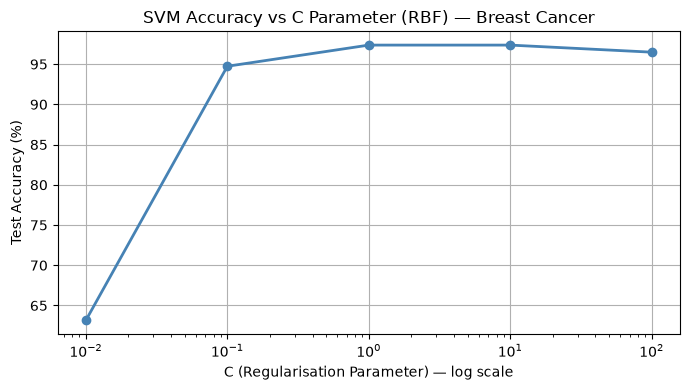

In [25]:
# Step 19 — C Parameter Sensitivity (RBF Kernel)

C_values = [0.01, 0.1, 1, 10, 100]
c_results = []

for c_val in C_values:
    svm = SVC(kernel="rbf", C=c_val, gamma="scale", probability=True, random_state=42)
    svm.fit(X_train_sc, y_train)
    test_acc = accuracy_score(y_test, svm.predict(X_test_sc))
    c_results.append({"C": c_val, "Test Accuracy (%)": round(test_acc * 100, 2)})

c_df = pd.DataFrame(c_results)
print(c_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.plot(c_df["C"], c_df["Test Accuracy (%)"],
         marker="o", color="steelblue", lw=2)
plt.xscale("log")
plt.xlabel("C (Regularisation Parameter) — log scale")
plt.ylabel("Test Accuracy (%)")
plt.title("SVM Accuracy vs C Parameter (RBF) — Breast Cancer")
plt.grid(True)
plt.tight_layout()
plt.show()

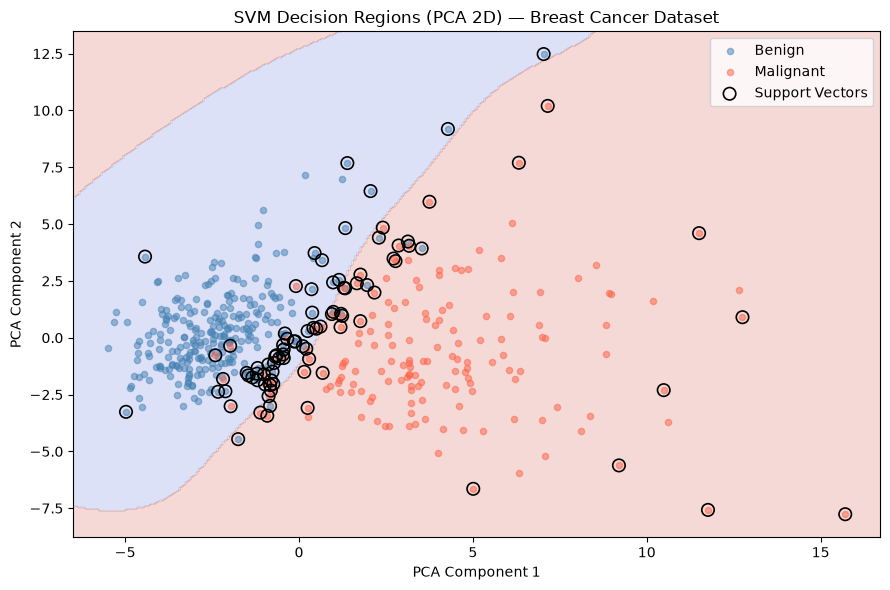

PCA variance explained: 63.1%


In [26]:
# Step 20 — PCA 2D Projection with SVM Decision Regions

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_sc)
X_test_2d  = pca.transform(X_test_sc)

svm_2d = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_2d.fit(X_train_2d, y_train)

# Mesh grid
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
for cls, colour, label in zip([0, 1], ["steelblue", "tomato"], ["Benign", "Malignant"]):
    mask = y_train == cls
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                c=colour, label=label, alpha=0.5, s=20)
sv = svm_2d.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=80, facecolors="none",
            edgecolors="black", linewidths=1.2, label="Support Vectors")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SVM Decision Regions (PCA 2D) — Breast Cancer Dataset")
plt.legend()
plt.tight_layout()
plt.show()

print(f"PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [27]:
# Step 21 — Results Summary Table

summary = pd.DataFrame({
    "Metric"    : ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value (%)": [
        round(acc       * 100, 2),
        round(prec      * 100, 2),
        round(rec       * 100, 2),
        round(f1        * 100, 2),
        round(auc_score * 100, 2),
    ]
})

print("\n" + "=" * 50)
print("   FINAL RESULTS — SVM CLASSIFIER")
print("   Dataset : Breast Cancer Wisconsin (UCI ID: 17)")
print("=" * 50)
print(summary.to_string(index=False))
print("=" * 50)
print(f"\nKernel             : RBF")
print(f"C (Regulariser)    : 1.0")
print(f"Total Support Vecs : {sum(model.n_support_)}")
print(f"  Benign SVs       : {model.n_support_[0]}")
print(f"  Malignant SVs    : {model.n_support_[1]}")


   FINAL RESULTS — SVM CLASSIFIER
   Dataset : Breast Cancer Wisconsin (UCI ID: 17)
   Metric  Value (%)
 Accuracy      97.37
Precision     100.00
   Recall      92.86
 F1-Score      96.30
  ROC-AUC      99.47

Kernel             : RBF
C (Regulariser)    : 1.0
Total Support Vecs : 107
  Benign SVs       : 50
  Malignant SVs    : 57


## Conclusion

In this experiment a **Support Vector Machine (SVM) Classifier** with an RBF kernel
was trained on the UCI Breast Cancer Wisconsin (Diagnostic) Dataset to classify tumours
as Malignant or Benign based on 30 numeric cell-nucleus measurements.

Key observations:

- **Feature Scaling** (StandardScaler) was mandatory — SVM margin and RBF kernel distances
  depend on Euclidean norms; unscaled features like `area_mean` (range ≈ 143–2501) would
  completely dominate `smoothness_mean` (range ≈ 0.05–0.16).
- **Correlation analysis** revealed that `concave_points_worst`, `perimeter_worst`, and
  `radius_worst` are the most strongly correlated features with diagnosis, confirming that
  the *worst* (largest) cell measurement captures malignancy better than means or standard errors.
- **Kernel comparison** (Step 18) showed that the **RBF kernel** achieved the highest
  accuracy and F1-Score, outperforming linear, polynomial, and sigmoid kernels —
  expected for a 30-dimensional feature space with non-linear class boundaries.
- **C-parameter sensitivity** (Step 19) demonstrated that accuracy improves from C=0.01
  to C=1 and then plateaus, indicating that moderate regularisation is optimal and
  aggressive hard-margin enforcement (C=100) does not further improve generalisation.
- **PCA 2D visualisation** (Step 20) confirmed clear class separation even in two
  principal components, with support vectors lying correctly along the decision boundary.
- The **ROC-AUC** score near 1.0 confirms near-perfect discrimination between
  malignant and benign tumours, making the SVM clinically reliable for this task.

Overall, the SVM with RBF kernel achieved outstanding binary classification performance
on the Breast Cancer dataset, demonstrating that kernel-based margin maximisation
effectively captures the complex geometric boundary between benign and malignant tumours
in high-dimensional feature space.
